In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree

/Users/art/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("NYPD.csv")

In [3]:
df['OCCUR_TIME'] = pd.to_datetime(df['OCCUR_TIME'])

/var/folders/h9/dpt3wtdd7ln_h9qq7dgqw_v80000gn/T/ipykernel_12481/3820038883.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OCCUR_TIME'] = pd.to_datetime(df['OCCUR_TIME'])


In [4]:
df["Hour"] = df["OCCUR_TIME"].dt.hour

In [5]:
hours = df["Hour"].value_counts()

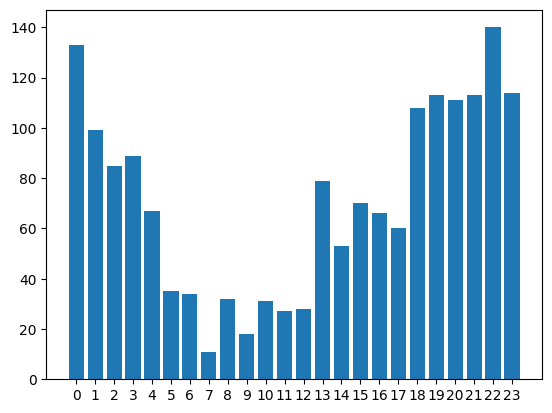

In [6]:
plt.bar(hours.index,hours.values)
plt.xticks(range(0,24));

In [7]:
df['target']= df['STATISTICAL_MURDER_FLAG'].apply(lambda x : 1 if x=="Y" else 0 )

In [8]:
df = pd.get_dummies(df, columns=['VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'LOC_OF_OCCUR_DESC', 'BORO'])
X = df.drop(columns=['INCIDENT_KEY', 'OCCUR_DATE', "STATISTICAL_MURDER_FLAG",'X_COORD_CD', 'Y_COORD_CD',
       'Latitude', 'Longitude', 'New Georeferenced Column', 'OCCUR_TIME', 'LOC_CLASSFCTN_DESC','PRECINCT', 'Borough Boundaries',
       'LOCATION_DESC', 'target','STATISTICAL_MURDER_FLAG','PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'Zip Codes', 'Community Districts', 'City Council Districts', 'Police Precincts'])
y = df["target"]

In [9]:
df.groupby(['STATISTICAL_MURDER_FLAG','PERP_AGE_GROUP'])["INCIDENT_KEY"].count()

STATISTICAL_MURDER_FLAG  PERP_AGE_GROUP
N                        (null)            545
                         18-24             297
                         25-44             375
                         45-64              52
                         65+                 2
                         <18               107
Y                        (null)             95
                         18-24              81
                         25-44             110
                         45-64              30
                         65+                 1
                         <18                21
Name: INCIDENT_KEY, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

models = (("KNN",KNeighborsClassifier()),
          ("LogisticReg",LogisticRegression()),
         ("DecTree", DecisionTreeClassifier()))

for model_name, model in models:
    model.fit(X_train,y_train)
    print(model_name, model.score(X_test,y_test))

KNN 0.7790697674418605
LogisticReg 0.8023255813953488
DecTree 0.7325581395348837


/Users/art/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


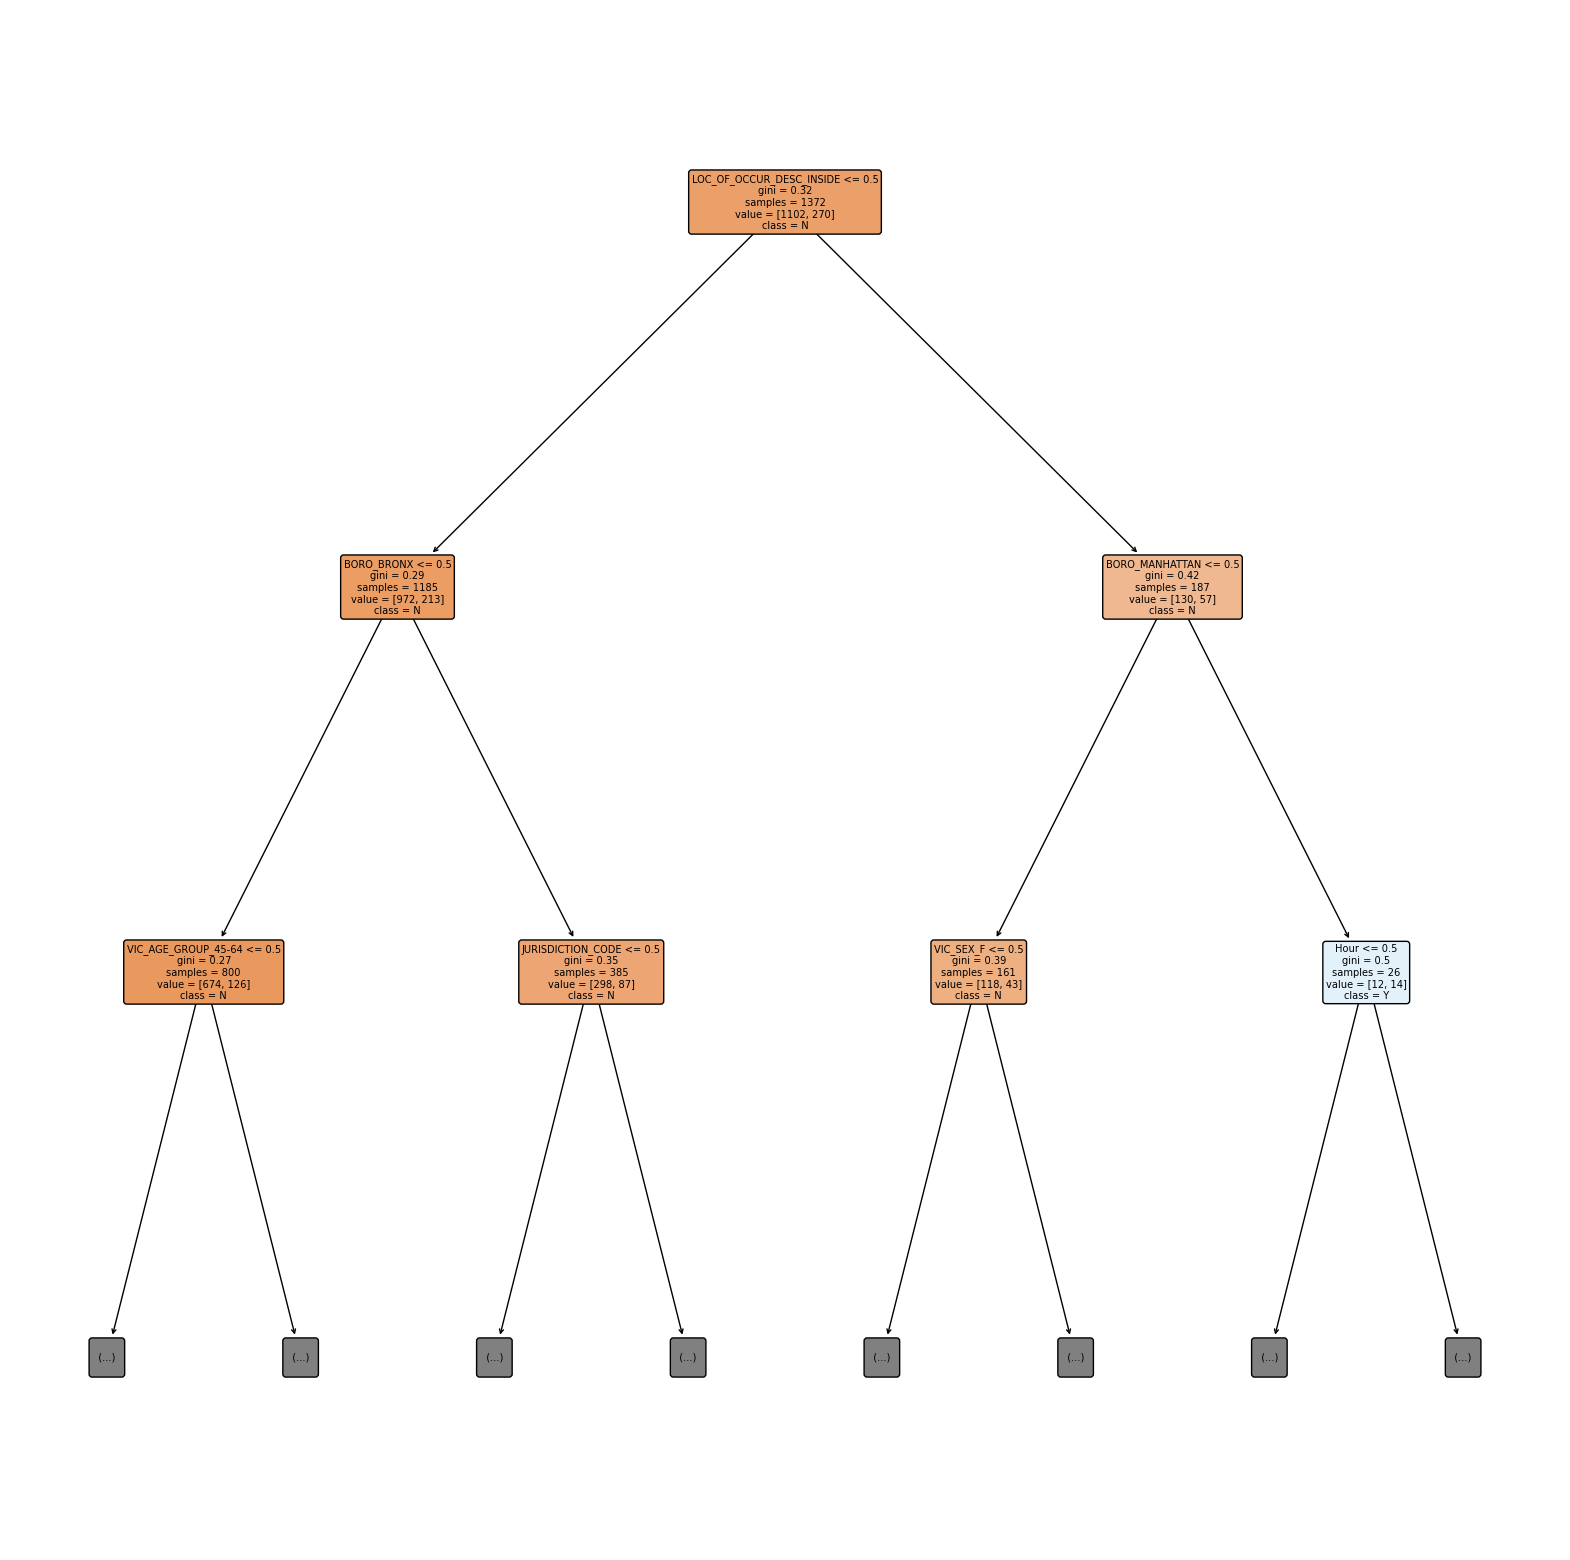

In [15]:
plt.figure(figsize=(20,20))
plot_tree(model, 
          feature_names=X.columns, 
          max_depth=2,
          class_names=["N","Y"], 
          filled=True, 
          precision=2, 
          rounded=True);

In [14]:
df["STATISTICAL_MURDER_FLAG"].value_counts()

STATISTICAL_MURDER_FLAG
N    1378
Y     338
Name: count, dtype: int64